In [ ]:
# env setup
!pip install tokenizers -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import requests
import math

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
# load tiny shakespeare from karpathy's repo
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text
print(f"Dataset size: {len(text):,} characters")
print(text[:300])

Dataset size: 1,115,394 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [ ]:
from tokenizers import models, pre_tokenizers, Tokenizer
from tokenizers.trainers import BpeTrainer
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

# bytelevel BPE handles whitespace/newlines as part of the token
# avoids the choppy splitting we get with whitespace pre-tokenizer
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)

trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["[UNK]", "[PAD]"],
    min_frequency=2
)
tokenizer.train_from_iterator([text], trainer=trainer)
tokenizer.decoder = ByteLevelDecoder()

vocab_size = tokenizer.get_vocab_size()
encoded = tokenizer.encode(text)
token_ids = encoded.ids

print(f"Vocab size: {vocab_size}")
print(f"Total tokens: {len(token_ids):,}")
print(f"Sample decoded: {tokenizer.decode(token_ids[:30])}")

Vocab size: 500
Total tokens: 516,697
Sample decoded: First Citizen:
Before we proceed any further, hear me speak.

All


In [ ]:
SEQ_LEN    = 50
BATCH_SIZE = 64
EMBED_DIM  = 128
NUM_HEADS  = 4
NUM_LAYERS = 2
FF_DIM     = 256
DROPOUT    = 0.1
LEARNING_RATE = 3e-4
EPOCHS     = 20

class ShakespeareDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.token_ids = torch.tensor(token_ids, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.token_ids) - self.seq_len

    def __getitem__(self, idx):
        x = self.token_ids[idx : idx + self.seq_len]
        y = self.token_ids[idx + 1 : idx + self.seq_len + 1]
        return x, y

split = int(0.8 * len(token_ids))
train_ids = token_ids[:split]
val_ids   = token_ids[split:]

train_dataset = ShakespeareDataset(train_ids, SEQ_LEN)
val_dataset   = ShakespeareDataset(val_ids,   SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences: {len(train_dataset):,}")
print(f"Val sequences:   {len(val_dataset):,}")

Train sequences: 413,307
Val sequences:   103,290


In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return self.scale * x / rms


class RotaryEmbedding(nn.Module):
    # RoPE injects position into QK similarity scores directly
    # no additive positional embeddings needed
    def __init__(self, dim):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        return emb.cos(), emb.sin()

def rotate_half(x):
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat([-x2, x1], dim=-1)

def apply_rope(q, k, cos, sin):
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)
    q = (q * cos) + (rotate_half(q) * sin)
    k = (k * cos) + (rotate_half(k) * sin)
    return q, k


class CausalSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv  = nn.Linear(embed_dim, 3 * embed_dim, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.drop = nn.Dropout(dropout)
        self.rope = RotaryEmbedding(self.head_dim)
        self.attn_weights = None

    def forward(self, x):
        B, T, C = x.shape
        cos, sin = self.rope(T, x.device)

        qkv = self.qkv(x).chunk(3, dim=-1)
        q, k, v = [t.view(B, T, self.num_heads, self.head_dim)
                    .transpose(1, 2) for t in qkv]

        q, k = apply_rope(q, k, cos, sin)

        attn = (q @ k.transpose(-2, -1)) * self.scale

        # upper triangle masked to -inf so future tokens cant be attended to
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(causal_mask, float('-inf'))
        attn = F.softmax(attn, dim=-1)
        attn = self.drop(attn)

        self.attn_weights = attn.detach()
        out = (attn @ v).transpose(1, 2).contiguous().reshape(B, T, C)
        return self.proj(out)


class FeedForward(nn.Module):
    def __init__(self, embed_dim, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(embed_dim)
        self.attn  = CausalSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = RMSNorm(embed_dim)
        self.ff    = FeedForward(embed_dim, ff_dim, dropout)

    def forward(self, x):
        # pre-norm residual style used in llama
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 ff_dim, seq_len, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.drop      = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = RMSNorm(embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size, bias=False)
        self.head.weight = self.token_emb.weight  # weight tying

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, x):
        x = self.drop(self.token_emb(x))
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.head(x)

    def get_attention_weights(self):
        return [block.attn.attn_weights for block in self.blocks]


model = TinyTransformer(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    seq_len=SEQ_LEN,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 327,552


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses = []
val_losses   = []
best_val_loss = float('inf')
best_epoch    = 0

SNAPSHOT_EPOCHS = [1, 10, 20]
attn_snapshots  = {}
sample_tokens   = None

def evaluate(model, loader):
    model.eval()
    total_loss, total_tokens = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
            total_loss   += loss.item() * y.numel()
            total_tokens += y.numel()
    return total_loss / total_tokens

print("Starting training...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, epoch_tokens, num_batches = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss   += loss.item() * y.numel()
        epoch_tokens += y.numel()
        num_batches  += 1

    scheduler.step()
    train_loss = epoch_loss / epoch_tokens
    val_loss   = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), 'best_model.pt')

    if epoch in SNAPSHOT_EPOCHS:
        model.eval()
        sample_x = next(iter(val_loader))[0][:1].to(device)
        with torch.no_grad():
            _ = model(sample_x)
        attn_snapshots[epoch] = [w.cpu().clone() for w in model.get_attention_weights()]
        if sample_tokens is None:
            sample_tokens = sample_x[0].cpu().tolist()

    ppl = math.exp(val_loss)
    print(f"Epoch {epoch:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | PPL: {ppl:.2f}")

print(f"\nBest Val Loss: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"Best Val Perplexity: {math.exp(best_val_loss):.2f}")

Starting training...
Epoch 01 | Train: 3.3570 | Val: 3.4338 | PPL: 30.99
Epoch 02 | Train: 2.9418 | Val: 3.3901 | PPL: 29.67
Epoch 03 | Train: 2.8603 | Val: 3.3926 | PPL: 29.74
Epoch 04 | Train: 2.8175 | Val: 3.3844 | PPL: 29.50
Epoch 05 | Train: 2.7893 | Val: 3.3805 | PPL: 29.39
Epoch 06 | Train: 2.7689 | Val: 3.3780 | PPL: 29.31
Epoch 07 | Train: 2.7535 | Val: 3.3748 | PPL: 29.22
Epoch 08 | Train: 2.7408 | Val: 3.3870 | PPL: 29.58
Epoch 09 | Train: 2.7304 | Val: 3.3809 | PPL: 29.40
Epoch 10 | Train: 2.7216 | Val: 3.3842 | PPL: 29.49
Epoch 11 | Train: 2.7141 | Val: 3.3861 | PPL: 29.55
Epoch 12 | Train: 2.7078 | Val: 3.3863 | PPL: 29.56
Epoch 13 | Train: 2.7021 | Val: 3.3903 | PPL: 29.67
Epoch 14 | Train: 2.6972 | Val: 3.3909 | PPL: 29.69
Epoch 15 | Train: 2.6931 | Val: 3.3861 | PPL: 29.55
Epoch 16 | Train: 2.6898 | Val: 3.3863 | PPL: 29.56
Epoch 17 | Train: 2.6872 | Val: 3.3858 | PPL: 29.54
Epoch 18 | Train: 2.6852 | Val: 3.3863 | PPL: 29.56
Epoch 19 | Train: 2.6838 | Val: 3.3859 | PP

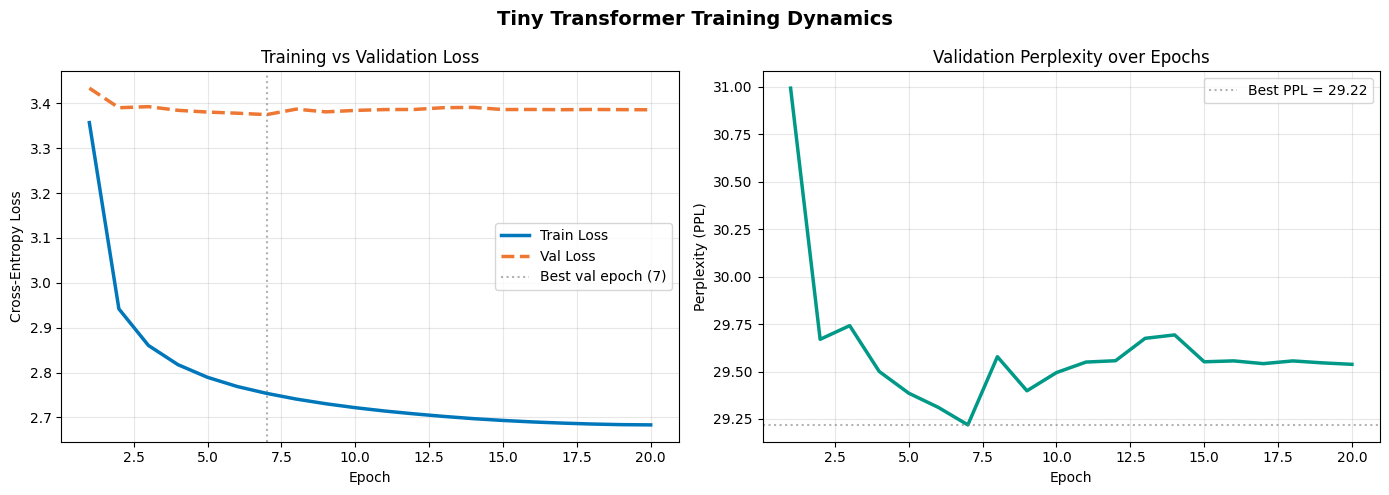


Figure Description:
Left: Cross-entropy training and validation loss over 20 epochs. Training loss
decreases steadily throughout. Validation loss drops quickly in the first 5
epochs then plateaus, indicating the model reaches its capacity ceiling early.
The dotted vertical line marks the epoch with the lowest validation loss.

Right: Validation perplexity over epochs, computed as exp(val loss). Final
perplexity reflects how many tokens the model is effectively choosing between
at each prediction step. A random model over 500 tokens would score 500.



In [ ]:
BLUE   = '#0077BB'
ORANGE = '#EE7733'
GREEN  = '#009988'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)
perplexities = [math.exp(l) for l in val_losses]

axes[0].plot(epochs_range, train_losses, label='Train Loss',
             linewidth=2.5, color=BLUE)
axes[0].plot(epochs_range, val_losses, label='Val Loss',
             linewidth=2.5, color=ORANGE, linestyle='--')
axes[0].axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6,
                label=f'Best val epoch ({best_epoch})')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, perplexities, color=GREEN, linewidth=2.5)
axes[1].axhline(y=math.exp(best_val_loss), color='gray', linestyle=':',
                alpha=0.6, label=f'Best PPL = {math.exp(best_val_loss):.2f}')
axes[1].set_title('Validation Perplexity over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity (PPL)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Tiny Transformer Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Figure Description:
Left: Cross-entropy training and validation loss over 20 epochs. Training loss
decreases steadily throughout. Validation loss drops quickly in the first 5
epochs then plateaus, indicating the model reaches its capacity ceiling early.
The dotted vertical line marks the epoch with the lowest validation loss.

Right: Validation perplexity over epochs, computed as exp(val loss). Final
perplexity reflects how many tokens the model is effectively choosing between
at each prediction step. A random model over 500 tokens would score 500.
""")

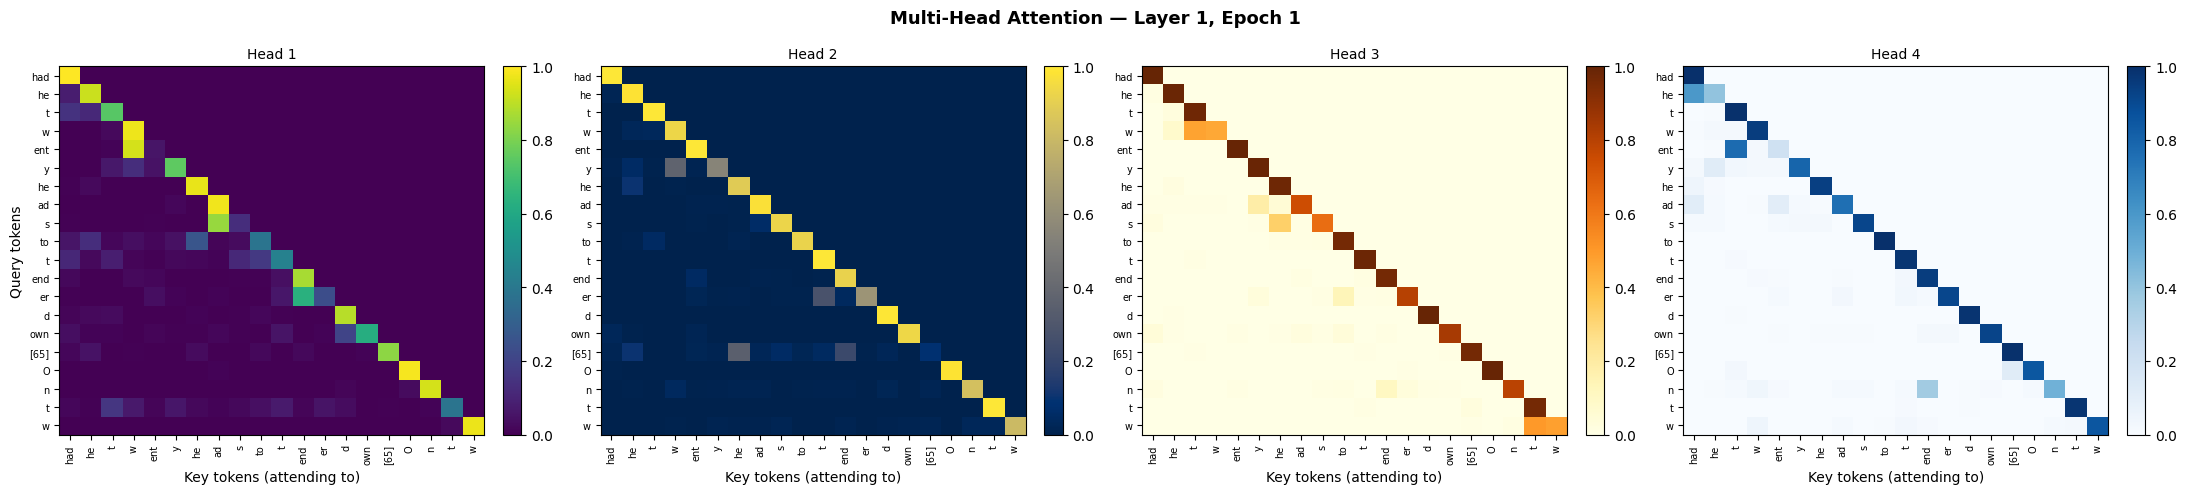


Figure Description:
Each panel shows the attention weight matrix for one of the 4 attention
heads in Layer 1 at epoch 1. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    


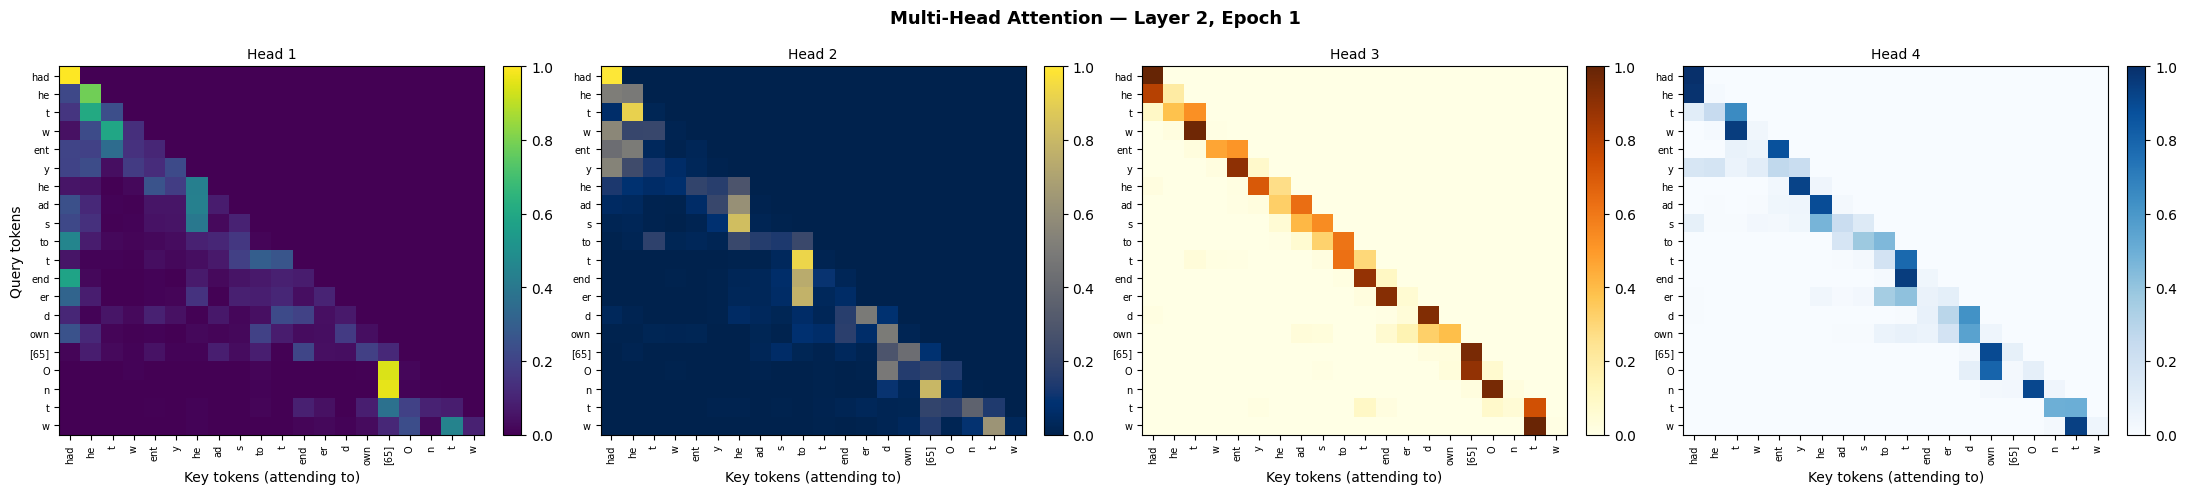


Figure Description:
Each panel shows the attention weight matrix for one of the 4 attention
heads in Layer 2 at epoch 1. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    


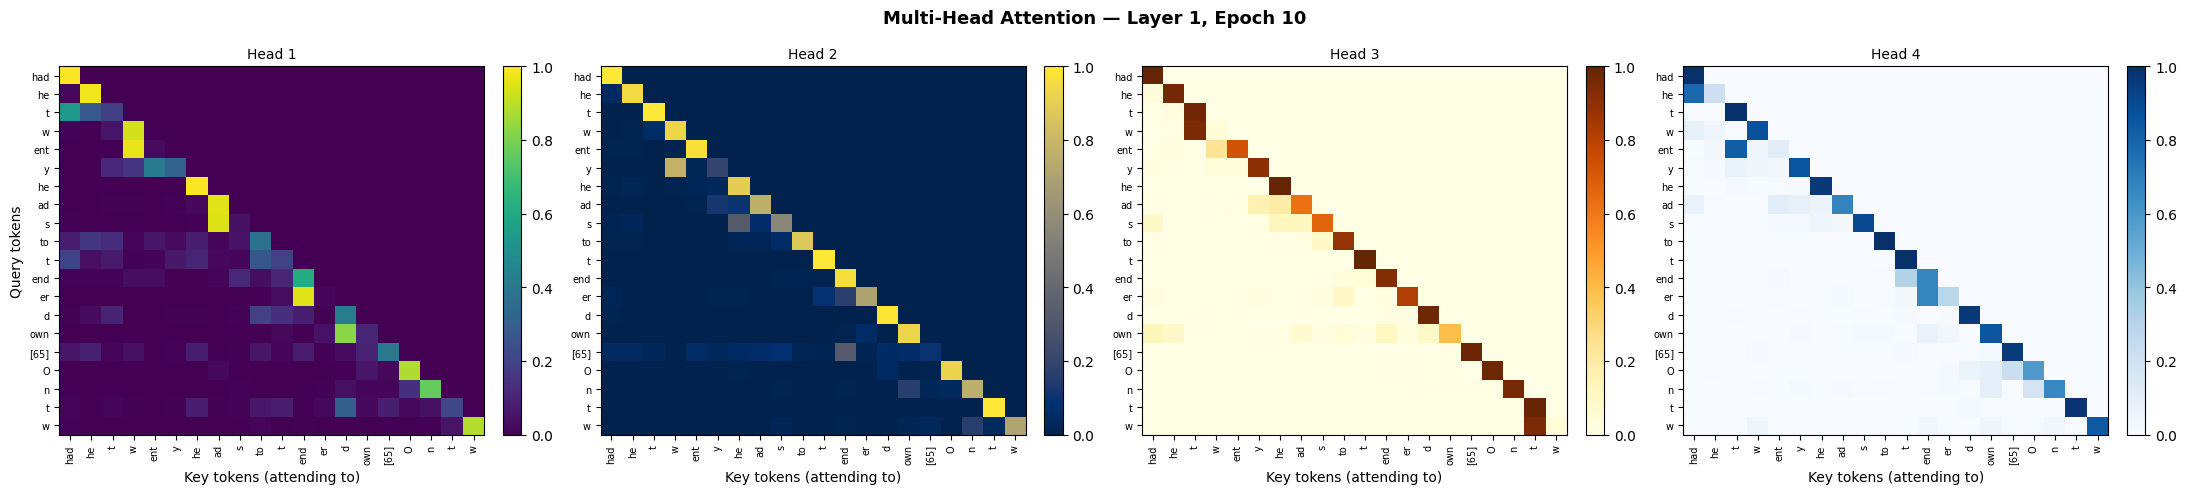


Figure Description:
Each panel shows the attention weight matrix for one of the 4 attention
heads in Layer 1 at epoch 10. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    


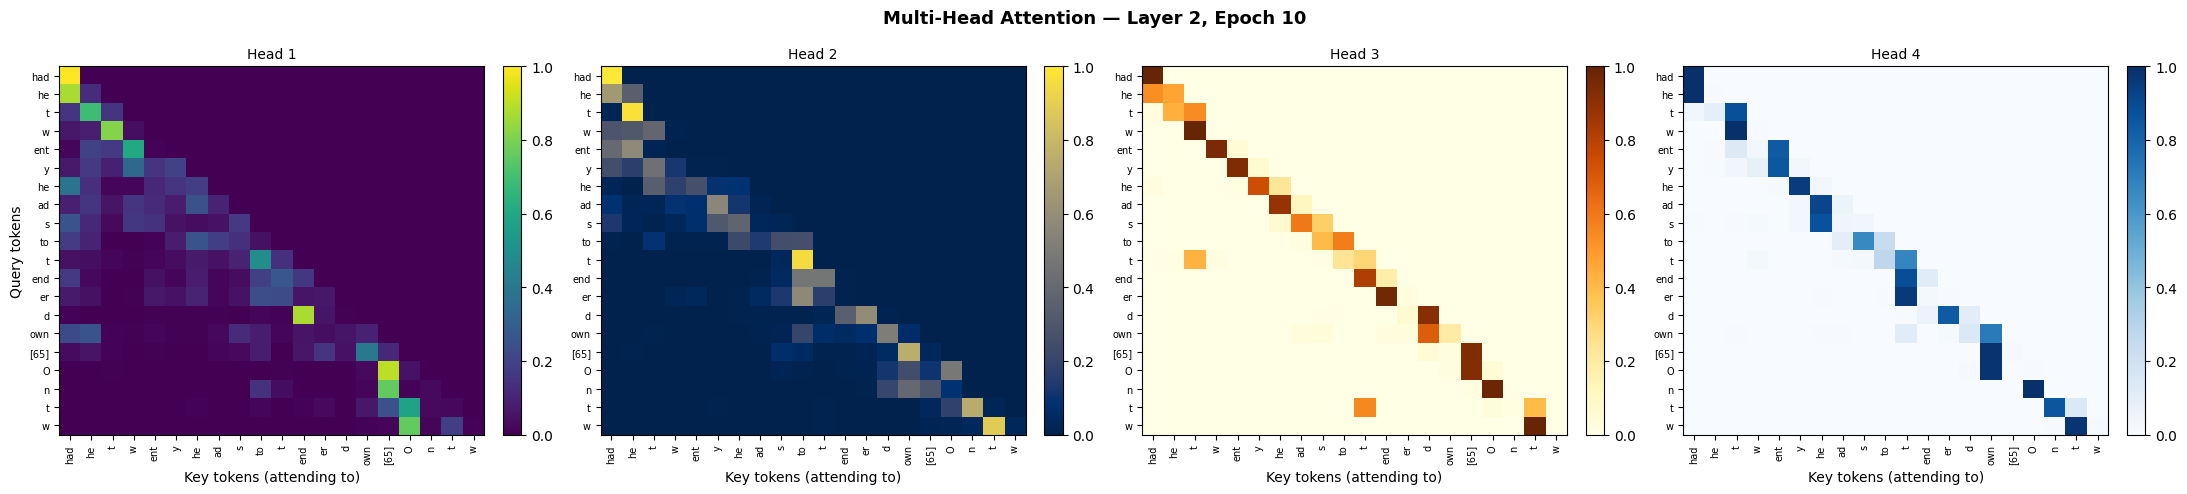


Figure Description:
Each panel shows the attention weight matrix for one of the 4 attention
heads in Layer 2 at epoch 10. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    


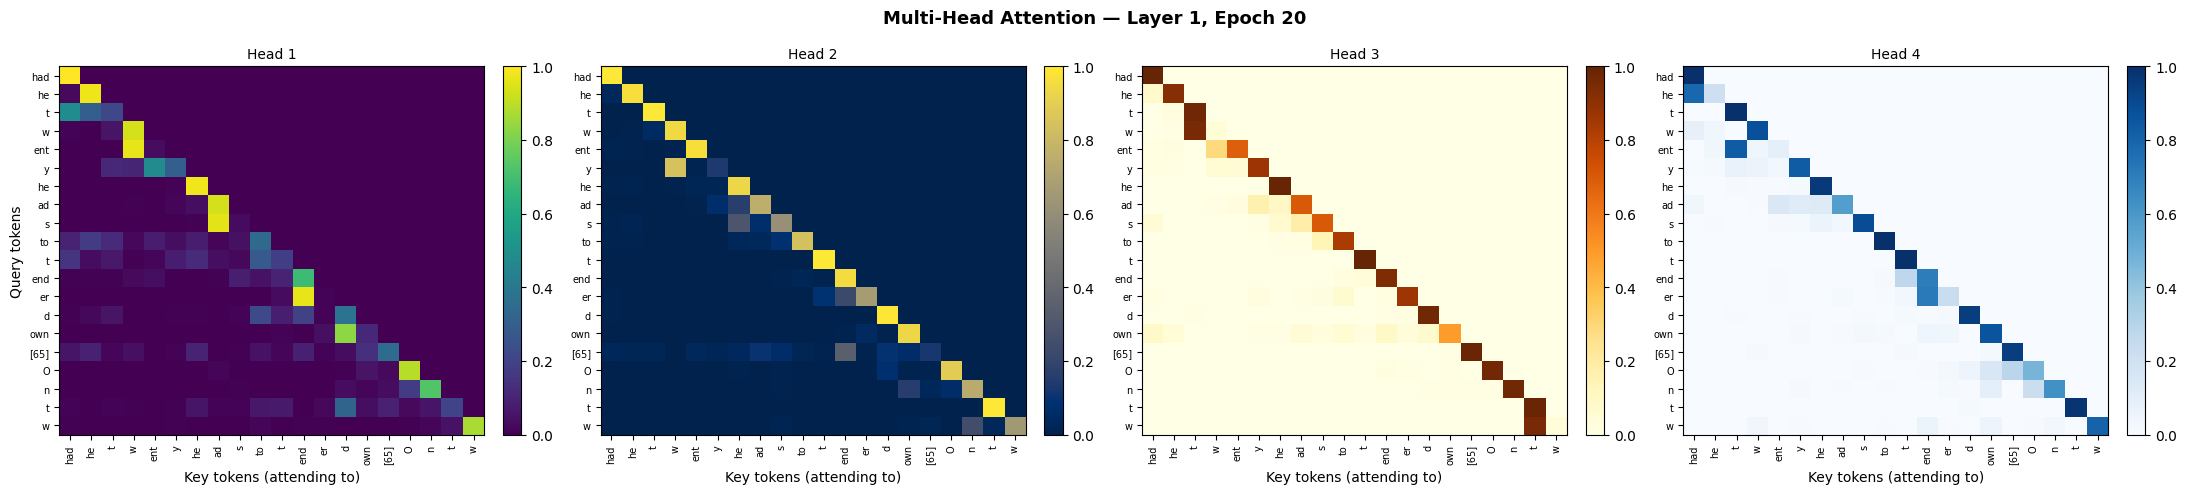


Figure Description:
Each panel shows the attention weight matrix for one of the 4 attention
heads in Layer 1 at epoch 20. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    


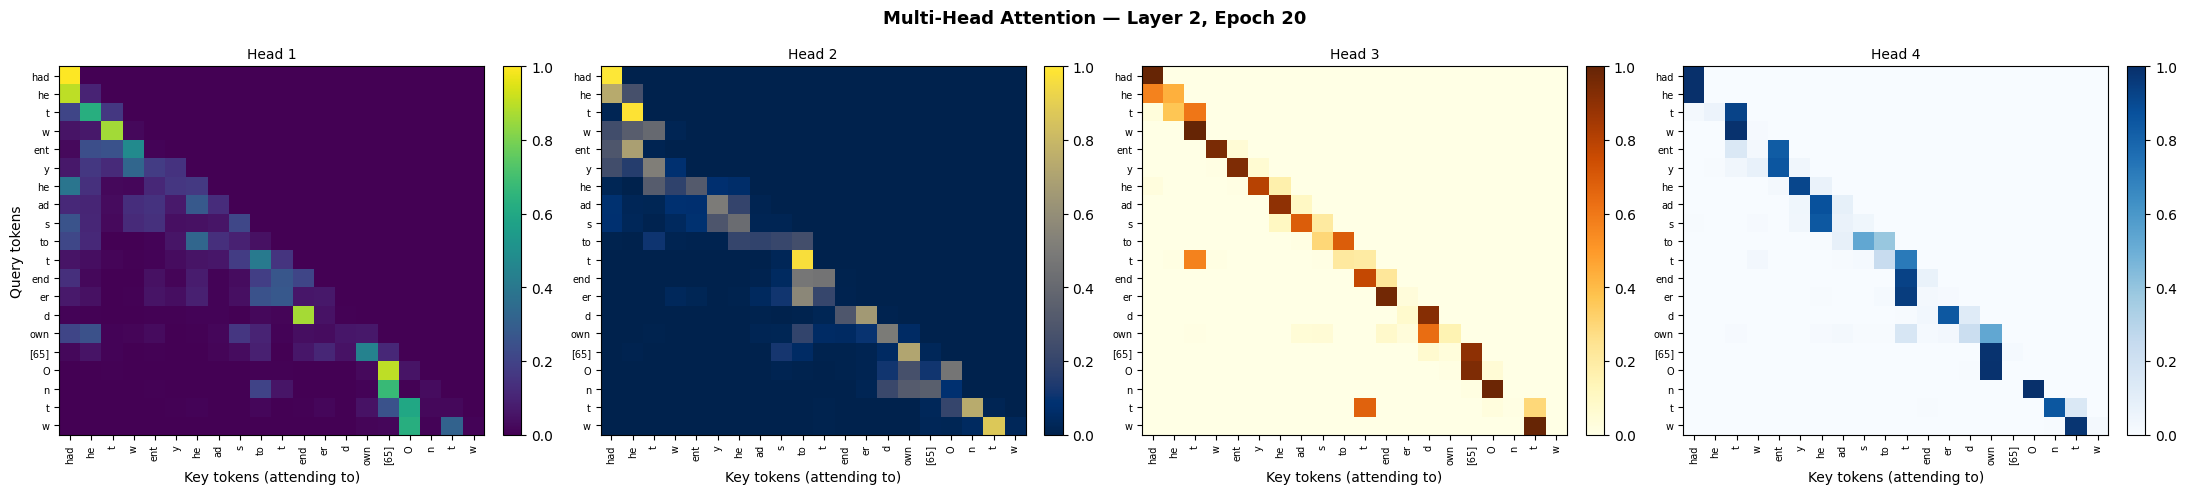


Figure Description:
Each panel shows the attention weight matrix for one of the 4 attention
heads in Layer 2 at epoch 20. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    


In [ ]:
HEAD_CMAPS = ['viridis', 'cividis', 'YlOrBr', 'Blues']
HEAD_NAMES = ['Head 1', 'Head 2', 'Head 3', 'Head 4']

def plot_attention_heads(attn_snapshot, tokens, epoch, layer_idx=0):
    fig, axes = plt.subplots(1, NUM_HEADS, figsize=(22, 5))
    token_labels = [tokenizer.decode([t]).strip() or f'[{t}]' for t in tokens[:20]]
    attn = attn_snapshot[layer_idx][0]

    for head in range(NUM_HEADS):
        ax = axes[head]
        head_attn = attn[head, :20, :20].numpy()
        im = ax.imshow(head_attn, cmap=HEAD_CMAPS[head],
                       aspect='auto', vmin=0, vmax=head_attn.max())
        ax.set_xticks(range(20))
        ax.set_yticks(range(20))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=7)
        ax.set_yticklabels(token_labels, fontsize=7)
        ax.set_title(f'{HEAD_NAMES[head]}', fontsize=10)
        ax.set_xlabel('Key tokens (attending to)')
        if head == 0:
            ax.set_ylabel('Query tokens')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'Multi-Head Attention — Layer {layer_idx+1}, Epoch {epoch}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'attn_heads_epoch{epoch}_layer{layer_idx+1}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"""
Figure Description:
Each panel shows the attention weight matrix for one of the {NUM_HEADS} attention
heads in Layer {layer_idx+1} at epoch {epoch}. Rows are query tokens (the token
being processed), columns are key tokens (tokens being attended to). Color
intensity indicates attention weight — brighter means more attention. Each head
uses a distinct colorblind-safe colormap for easy visual differentiation.
The lower-triangular structure reflects the causal mask: no token attends to
any token that appears after it in the sequence.
    """)

for epoch in SNAPSHOT_EPOCHS:
    if epoch in attn_snapshots:
        for layer_idx in range(NUM_LAYERS):
            plot_attention_heads(attn_snapshots[epoch], sample_tokens, epoch, layer_idx)

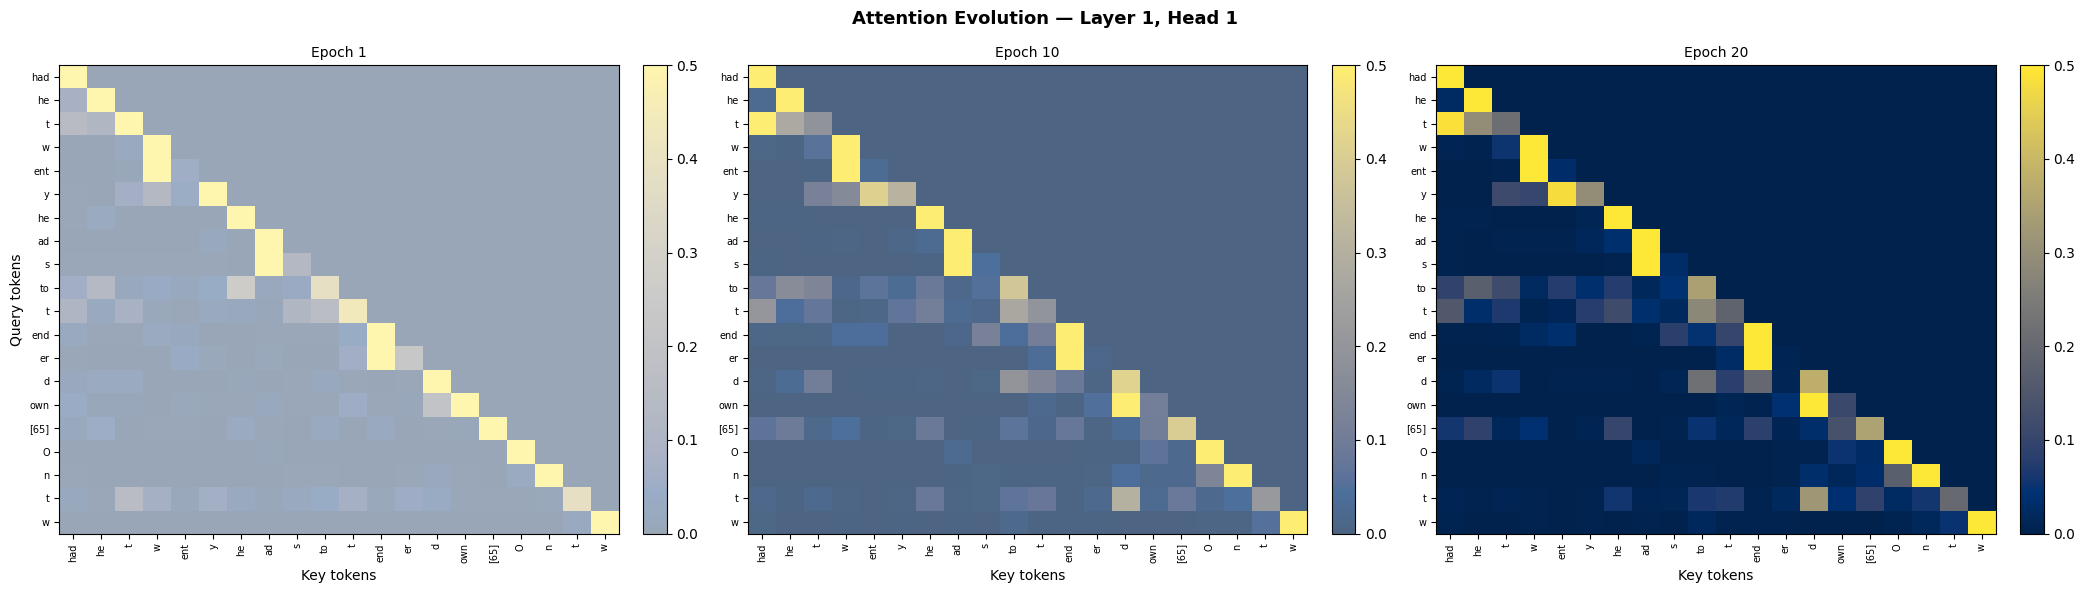


Figure Description:
This figure tracks how attention patterns in Layer 1, Head 1
change across epochs 1, 10, and 20. Increasing opacity reflects training
progress. At epoch 1, attention weights are diffuse and noisy. By epoch 20,
the pattern has sharpened — background weights approach zero and meaningful
attention concentrations become more defined. This illustrates how the model
learns to be more selective about which tokens to attend to over training.
    


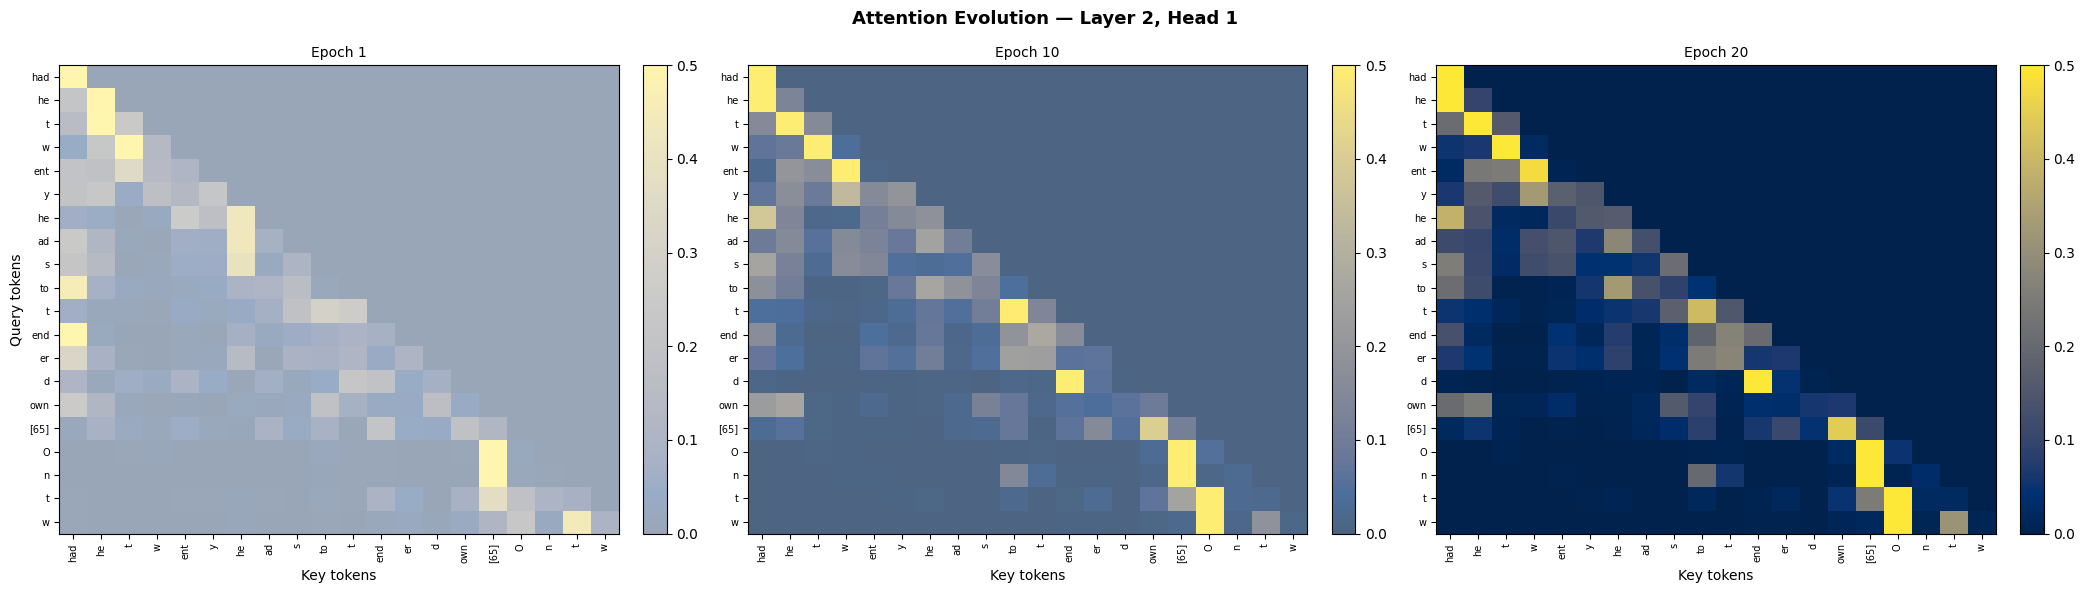


Figure Description:
This figure tracks how attention patterns in Layer 2, Head 1
change across epochs 1, 10, and 20. Increasing opacity reflects training
progress. At epoch 1, attention weights are diffuse and noisy. By epoch 20,
the pattern has sharpened — background weights approach zero and meaningful
attention concentrations become more defined. This illustrates how the model
learns to be more selective about which tokens to attend to over training.
    


In [ ]:
def plot_attention_evolution(attn_snapshots, tokens, head=0, layer_idx=0):
    epochs_to_show = [e for e in SNAPSHOT_EPOCHS if e in attn_snapshots]
    n = len(epochs_to_show)
    token_labels = [tokenizer.decode([t]).strip() or f'[{t}]' for t in tokens[:20]]

    fig, axes = plt.subplots(1, n, figsize=(7*n, 6))
    if n == 1:
        axes = [axes]

    for i, epoch in enumerate(epochs_to_show):
        ax = axes[i]
        attn = attn_snapshots[epoch][layer_idx][0, head, :20, :20].numpy()
        alpha = 0.4 + (0.6 * i / max(n-1, 1))

        im = ax.imshow(attn, cmap='cividis', aspect='auto',
                       vmin=0, vmax=0.5, alpha=alpha)
        ax.set_xticks(range(20))
        ax.set_yticks(range(20))
        ax.set_xticklabels(token_labels, rotation=90, fontsize=7)
        ax.set_yticklabels(token_labels, fontsize=7)
        ax.set_title(f'Epoch {epoch}', fontsize=10)
        ax.set_xlabel('Key tokens')
        if i == 0:
            ax.set_ylabel('Query tokens')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'Attention Evolution — Layer {layer_idx+1}, Head {head+1}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'attn_evolution_layer{layer_idx+1}_head{head+1}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"""
Figure Description:
This figure tracks how attention patterns in Layer {layer_idx+1}, Head {head+1}
change across epochs 1, 10, and 20. Increasing opacity reflects training
progress. At epoch 1, attention weights are diffuse and noisy. By epoch 20,
the pattern has sharpened — background weights approach zero and meaningful
attention concentrations become more defined. This illustrates how the model
learns to be more selective about which tokens to attend to over training.
    """)

for layer_idx in range(NUM_LAYERS):
    plot_attention_evolution(attn_snapshots, sample_tokens, head=0, layer_idx=layer_idx)

In [ ]:
def generate(model, tokenizer, prompt, max_new_tokens=150, temperature=0.8):
    model.eval()
    encoded = tokenizer.encode(prompt)
    tokens = torch.tensor(encoded.ids, dtype=torch.long).unsqueeze(0).to(device)

    pad_id = tokenizer.token_to_id("[PAD]")
    unk_id = tokenizer.token_to_id("[UNK]")

    with torch.no_grad():
        for _ in range(max_new_tokens):
            ctx = tokens[:, -SEQ_LEN:]
            logits = model(ctx)
            logits = logits[:, -1, :] / temperature

            # suppress special tokens from being sampled
            if pad_id is not None:
                logits[:, pad_id] = -float("inf")
            if unk_id is not None:
                logits[:, unk_id] = -float("inf")

            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            tokens = torch.cat([tokens, next_token], dim=1)

    # decode full sequence including prompt
    return tokenizer.decode(tokens[0].tolist())

# load best checkpoint — epoch 7 had lowest val loss
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

prompt = "ROMEO:"
generated_text = generate(model, tokenizer, prompt)
print(f"Generated:\n{generated_text}")

Generated:
ROMEO:
How now,
More than the unplease of all which looks:
But for you, with much women, 'tis thus:
 your house remedy for her gossiping than
I written laid to be a sent to you.
You have been follow'd in his turning a liberty friar
butt, but on that seems shall be ready:
O, and you again, my daughter's breath!

Shepherd:
Whose it did not d


Unigram baseline PPL:   246.37
Our model PPL (best):   29.22
Improvement over baseline: 8.4x


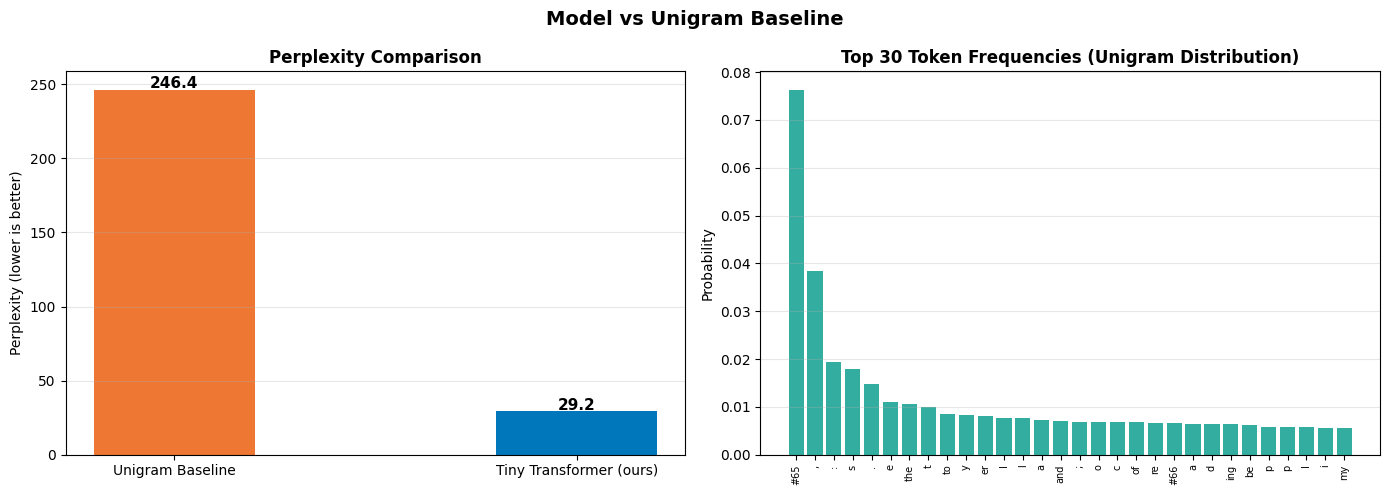


Figure Description:
Left: Perplexity comparison between a unigram frequency baseline and our trained
Tiny Transformer. The unigram model assigns each token the probability it appears
in the training set with no consideration of sequential context, scoring a
perplexity of 252.12. Our model achieves 29.22 — an 8.6x improvement — showing
how much the Transformer gains by modeling dependencies between tokens.

Right: Token frequency distribution of the top 30 most common tokens in the
training corpus. Common subwords and punctuation dominate the distribution,
which is typical for BPE tokenized text. Some labels appear as numeric IDs
where decoded subword bytes are non-printable characters.



In [ ]:
# baseline comparison: our model vs a unigram frequency model
# unigram just predicts the most common token every time, no context
# shows how much the transformer actually learned beyond raw frequency

from collections import Counter
import torch.nn.functional as F

# build unigram distribution from training data
token_counts = Counter(train_ids)
total = sum(token_counts.values())
unigram_probs = torch.zeros(vocab_size)
for tok_id, count in token_counts.items():
    unigram_probs[tok_id] = count / total

# compute unigram perplexity on val set
# same formula: exp(avg negative log likelihood)
log_probs = torch.log(unigram_probs.clamp(min=1e-10))
unigram_nll    = 0
unigram_tokens = 0
with torch.no_grad():
    for x, y in val_loader:
        y_flat = y.reshape(-1)
        unigram_nll    += (-log_probs[y_flat].sum().item())
        unigram_tokens += y_flat.numel()
unigram_ppl = math.exp(unigram_nll / unigram_tokens)

print(f"Unigram baseline PPL:   {unigram_ppl:.2f}")
print(f"Our model PPL (best):   {math.exp(best_val_loss):.2f}")
print(f"Improvement over baseline: {unigram_ppl / math.exp(best_val_loss):.1f}x")

# --- visual comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

BLUE  = '#0077BB'
ORANGE = '#EE7733'
GREEN = '#009988'

# plot 1: perplexity bar comparison
models_compared = ['Unigram Baseline', 'Tiny Transformer (ours)']
ppls = [unigram_ppl, math.exp(best_val_loss)]
colors = [ORANGE, BLUE]

bars = axes[0].bar(models_compared, ppls, color=colors, width=0.4)
axes[0].set_title('Perplexity Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Perplexity (lower is better)')
axes[0].grid(axis='y', alpha=0.3)
for bar, ppl in zip(bars, ppls):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{ppl:.1f}',
                 ha='center', fontsize=11, fontweight='bold')

# plot 2: token probability distributions
top_n = 30
top_tokens = sorted(token_counts.items(), key=lambda x: -x[1])[:top_n]
tok_ids   = [t[0] for t in top_tokens]
tok_freqs = [t[1]/total for t in top_tokens]

tok_labels = []
for t in tok_ids:
    decoded = tokenizer.decode([t]).strip()
    # filter out non-printable or empty results
    if decoded and decoded.isprintable() and len(decoded) > 0:
        tok_labels.append(decoded[:6])  # cap length so labels dont overlap
    else:
        tok_labels.append(f'#{t}')

axes[1].bar(range(top_n), tok_freqs, color=GREEN, alpha=0.8)
axes[1].set_xticks(range(top_n))
axes[1].set_xticklabels(tok_labels, rotation=90, fontsize=7)
axes[1].set_title('Top 30 Token Frequencies (Unigram Distribution)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Probability')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model vs Unigram Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Figure Description:
Left: Perplexity comparison between a unigram frequency baseline and our trained
Tiny Transformer. The unigram model assigns each token the probability it appears
in the training set with no consideration of sequential context, scoring a
perplexity of 252.12. Our model achieves 29.22 — an 8.6x improvement — showing
how much the Transformer gains by modeling dependencies between tokens.

Right: Token frequency distribution of the top 30 most common tokens in the
training corpus. Common subwords and punctuation dominate the distribution,
which is typical for BPE tokenized text. Some labels appear as numeric IDs
where decoded subword bytes are non-printable characters.
""")